In [1]:
import argparse
import re
from pathlib import Path
from typing import Any, Iterable, List, Tuple

import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
import pandas as pd
import seaborn as sns

from utils import safe_name


PLOT_METRICS = {
    "type_ii": {
        "column": "Cum. Type-II",
        "filename": "type_ii",
        "title": "Type-II error",
    },
    "type_i": {
        "column": "Cum. Type-I",
        "filename": "type_i",
        "title": "Type-I error",
    },
    "budget": {
        "column": "Cum. Budget",
        "filename": "budget",
        "title": "Budget",
    },
}


METHOD_ORDER = ["Ours", "Ours-LLM", "Ours-Random", "LLM-Select", "Random"]
# Edit this list to control which methods are drawn in the final plots.
# It initially includes every implemented method.
METHODS_TO_PLOT = METHOD_ORDER.copy()
METHOD_PALETTE = {
    "Ours": "#F2B701",          # yellow
    "Ours-LLM": "#1f77b4",      # blue
    "Ours-Random": "#9467bd",   # purple
    "LLM-Select": "#d62728",    # red
    "Random": "#2ca02c",        # green
}


KNOWN_METHOD_PREFIXES = ("llm_select", "ours_llm", "ours_random", "random", "ours")
KNOWN_DATASET_PATTERNS = (
    r"(gpqa-[^_]+_[^_]+_n[^_]+)(?=_budget|$)",
    r"(mmlupro-[^_]+_n[^_]+_seed[^_]+(?:_[A-Za-z0-9_.-]+)*)(?=_budget|$)",
    r"(popqa-[^_]+_n[^_]+_seed[^_]+(?:_[A-Za-z0-9_.-]+)*)(?=_budget|$)",
    r"(popqa500-[^_]+_n[^_]+_seed[^_]+(?:_[A-Za-z0-9_.-]+)*)(?=_budget|$)",
    r"(math500-[^_]+)(?=_budget|$)",
)


def _first_nonempty(series: pd.Series) -> str | None:
    for value in series.dropna().tolist():
        text = str(value).strip()
        if text:
            return text
    return None


def _known_dataset_from_text(text: str) -> str | None:
    """Extract dataset names used by this project from a run/cache stem."""
    text = str(text)
    for pattern in KNOWN_DATASET_PATTERNS:
        m = re.search(pattern, text)
        if m:
            return m.group(1).replace("popqa500-", "popqa-")
    return None


def infer_dataset_name(csv_path: Path, df: pd.DataFrame) -> str:
    """Infer the dataset identifier for a run CSV."""
    if "dataset" in df.columns:
        explicit = _first_nonempty(df["dataset"])
        if explicit:
            return safe_name(explicit).replace("popqa500-", "popqa-")

    stem = csv_path.stem.replace("popqa500-", "popqa-")
    if "config" in df.columns:
        config_name = _first_nonempty(df["config"])
        if config_name:
            stem = str(config_name).replace("popqa500-", "popqa-")

    known = _known_dataset_from_text(stem)
    if known:
        return safe_name(known)

    if "_budget" in stem:
        before_budget = stem.split("_budget", 1)[0]

        method = _first_nonempty(df["method"]) if "method" in df.columns else None
        if method:
            method_prefix = str(method).lower().replace("-", "_") + "_"
            if before_budget.startswith(method_prefix):
                before_budget = before_budget[len(method_prefix) :]
        else:
            for prefix in KNOWN_METHOD_PREFIXES:
                method_prefix = prefix + "_"
                if before_budget.startswith(method_prefix):
                    before_budget = before_budget[len(method_prefix) :]
                    break

        main_llm = _first_nonempty(df["main_llm"]) if "main_llm" in df.columns else None
        if main_llm:
            main_prefix = safe_name(main_llm) + "_"
            if before_budget.startswith(main_prefix):
                dataset = before_budget[len(main_prefix) :]
                if dataset:
                    return safe_name(dataset).replace("popqa500-", "popqa-")

        parts = before_budget.split("_", 1)
        if len(parts) == 2 and parts[1]:
            return safe_name(parts[1]).replace("popqa500-", "popqa-")

    return safe_name("unknown_dataset")


def infer_model_data_name(csv_path: Path, df: pd.DataFrame) -> str:
    """Infer the figure/output group: {main_llm}_{dataset}."""
    dataset = infer_dataset_name(csv_path, df)

    # If the CSV is already under outputs/{main_llm}_{dataset}/, use the folder.
    parent = csv_path.parent.name
    if parent.endswith(dataset) and "_" in parent:
        return safe_name(parent).replace("popqa500-", "popqa-")

    main_llm = _first_nonempty(df["main_llm"]) if "main_llm" in df.columns else None
    if main_llm:
        return f"{safe_name(main_llm)}_{dataset}"

    # Last fallback: parse the run filename.
    stem = csv_path.stem.replace("popqa500-", "popqa-")
    known = _known_dataset_from_text(stem)
    if known and known in stem:
        prefix = stem.split(known, 1)[0].rstrip("_")
        for method in KNOWN_METHOD_PREFIXES:
            method_prefix = method + "_"
            if prefix.startswith(method_prefix):
                prefix = prefix[len(method_prefix) :]
                break
        if prefix:
            return safe_name(f"{prefix}_{known}")

    return safe_name(dataset)


def collect_run_csvs(paths: List[str]) -> pd.DataFrame:
    frames = []

    for p in paths:
        path = Path(p)
        csvs = sorted(path.rglob("*.csv")) if path.is_dir() else [path]

        for csv in csvs:
            if csv.name.startswith("gen_") or csv.name.endswith("_metrics.csv"):
                continue
            df = pd.read_csv(csv)
            df["run_file"] = csv.stem.replace("popqa500-", "popqa-")
            df["run_path"] = str(csv)
            df["dataset"] = infer_dataset_name(csv, df)
            df["model_data"] = infer_model_data_name(csv, df)
            frames.append(df)

    if not frames:
        raise RuntimeError("No method run CSV files found.")

    return pd.concat(frames, ignore_index=True)


def pretty_method(name: str) -> str:
    mapping = {
        "ours": "Ours",
        "ours_llm": "Ours-LLM",
        "ours_random": "Ours-Random",
        "random": "Random",
        "llm_select": "LLM-Select",
    }
    return mapping.get(str(name), str(name))


def safe_div(num: float, den: float) -> float:
    return 0.0 if den <= 0 else float(num / den)


def summarize_per_round(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["model_data", "dataset", "config", "method", "run_file", "t"]

    for (model_data, dataset, config, method, run_file, t), g in df.groupby(group_cols, sort=True):
        selected = g["selected"].astype(int)
        A = g["A"].astype(int)
        cost = g["cost"].astype(float)

        n_sel = int(selected.sum())
        n_unsel = int((1 - selected).sum())

        selected_correct = float((selected * (1 - A)).sum())
        unselected_wrong = float(((1 - selected) * A).sum())
        used_budget = float((selected * cost).sum())

        rows.append(
            {
                "model_data": model_data,
                "dataset": dataset,
                "config": config,
                "method": method,
                "run_file": run_file,
                "Method": pretty_method(method),
                "Round": int(t),
                "Type-I": safe_div(selected_correct, n_sel),
                "Type-II": safe_div(unselected_wrong, n_unsel),
                "Budget": used_budget,
                "Limit": float(g["budget"].iloc[0]),
                "Selected": n_sel,
                "Unselected": n_unsel,
                "Selected correct": selected_correct,
                "Unselected wrong": unselected_wrong,
            }
        )

    return pd.DataFrame(rows)


def add_cumulative_metrics(round_df: pd.DataFrame) -> pd.DataFrame:
    round_df = round_df.sort_values(
        ["model_data", "dataset", "config", "method", "run_file", "Round"]
    ).reset_index(drop=True)

    group_cols = ["model_data", "dataset", "config", "method", "run_file"]
    round_index = round_df.groupby(group_cols).cumcount() + 1

    round_df["Cum. Type-I"] = round_df.groupby(group_cols)["Type-I"].cumsum() / round_index
    round_df["Cum. Type-II"] = round_df.groupby(group_cols)["Type-II"].cumsum() / round_index
    round_df["Cum. Budget"] = round_df.groupby(group_cols)["Budget"].cumsum() / round_index
    round_df["Avg. Budget"] = round_df["Cum. Budget"]

    round_df["Cum. Selected"] = round_df.groupby(group_cols)["Selected"].cumsum()
    round_df["Cum. Unselected"] = round_df.groupby(group_cols)["Unselected"].cumsum()
    round_df["Cum. Selected correct"] = round_df.groupby(group_cols)["Selected correct"].cumsum()
    round_df["Cum. Unselected wrong"] = round_df.groupby(group_cols)["Unselected wrong"].cumsum()

    round_df["Pooled Type-I"] = round_df.apply(
        lambda r: safe_div(r["Cum. Selected correct"], r["Cum. Selected"]),
        axis=1,
    )
    round_df["Pooled Type-II"] = round_df.apply(
        lambda r: safe_div(r["Cum. Unselected wrong"], r["Cum. Unselected"]),
        axis=1,
    )

    return round_df


def maybe_add_epsilon(metrics: pd.DataFrame, raw_df: pd.DataFrame) -> pd.DataFrame:
    if "epsilon" not in raw_df.columns:
        metrics["epsilon"] = pd.NA
        return metrics

    eps = raw_df[["model_data", "dataset", "config", "method", "run_file", "epsilon"]].drop_duplicates()
    eps = eps.dropna(subset=["epsilon"])
    if eps.empty:
        metrics["epsilon"] = pd.NA
        return metrics

    return metrics.merge(eps, on=["model_data", "dataset", "config", "method", "run_file"], how="left")


def filter_methods_for_plot(
    metrics: pd.DataFrame,
    methods_to_plot: List[str] = METHODS_TO_PLOT,
) -> pd.DataFrame:
    """Keep only the methods listed in METHODS_TO_PLOT before plotting."""
    if metrics.empty or "Method" not in metrics.columns:
        return metrics
    return metrics[metrics["Method"].isin(methods_to_plot)].copy()


def set_paper_style() -> None:
    sns.set_theme(context="paper", style="darkgrid", font_scale=1.2)
    plt.rcParams.update(
        {
            "figure.dpi": 150,
            "savefig.dpi": 300,
            "axes.linewidth": 0.9,
            "legend.frameon": False,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def _pad_ylim_for_reference_line(ax: plt.Axes, y_value: float) -> None:
    """Ensure an annotated horizontal reference line is not clipped."""
    ymin, ymax = ax.get_ylim()
    if ymin <= y_value <= ymax:
        return

    span = ymax - ymin
    if span <= 0:
        span = max(abs(y_value), 1.0)

    pad = 0.06 * span
    ymin = min(ymin, y_value - pad)
    ymax = max(ymax, y_value + pad)
    ax.set_ylim(ymin, ymax)


def _annotate_reference_line(ax: plt.Axes, y_value: float, text: str) -> None:
    """Place a reference-line label just inside the plotting area, near the y-axis."""
    _pad_ylim_for_reference_line(ax, y_value)
    transform = blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(
        0.015,
        y_value,
        text,
        transform=transform,
        ha="left",
        va="bottom",
        fontsize=9.5,
        color="black",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.0},
        clip_on=False,
    )


def _draw_metric_axis(metrics: pd.DataFrame, metric_key: str, ax: plt.Axes, legend: bool) -> None:
    meta = PLOT_METRICS[metric_key]
    y = meta["column"]

    sns.lineplot(
        data=metrics,
        x="Round",
        y=y,
        hue="Method",
        hue_order=[m for m in METHOD_ORDER if m in set(metrics["Method"])],
        palette=METHOD_PALETTE,
        linewidth=2.0,
        errorbar=None,
        legend=legend,
        ax=ax,
    )

    if metric_key == "type_i" and metrics["epsilon"].notna().any():
        epsilon = float(metrics["epsilon"].dropna().iloc[0])
        ax.axhline(
            epsilon,
            linestyle="--",
            linewidth=1.3,
            color="black",
            label="_nolegend_",
        )
        _annotate_reference_line(ax, epsilon, r"$\epsilon$")

    if metric_key == "budget":
        limit = float(metrics["Limit"].iloc[0])
        ax.axhline(
            limit,
            linestyle="--",
            linewidth=1.3,
            color="black",
            label="_nolegend_",
        )
        _annotate_reference_line(ax, limit, "Limit")

    ax.set_xlabel("Round")
    ax.set_ylabel("")
    ax.set_title(meta["title"])
    ax.grid(axis="y", alpha=0.22, linewidth=0.7)
    sns.despine(ax=ax)


def _dedupe_legend(handles: Iterable[Any], labels: Iterable[str]) -> Tuple[List[Any], List[str]]:
    seen = set()
    out_handles = []
    out_labels = []
    for handle, label in zip(handles, labels):
        if not label or label.startswith("_") or label in seen:
            continue
        seen.add(label)
        out_handles.append(handle)
        out_labels.append(label)
    return out_handles, out_labels


def save_metric_plot(metrics: pd.DataFrame, metric_key: str, out_dir: Path) -> None:
    meta = PLOT_METRICS[metric_key]

    fig, ax = plt.subplots(figsize=(4.35, 2.85))
    _draw_metric_axis(metrics, metric_key, ax=ax, legend=True)

    handles, labels = _dedupe_legend(*ax.get_legend_handles_labels())
    if handles:
        ax.legend(handles, labels, title=None, loc="best")

    fig.tight_layout(pad=0.35)
    for ext in ["pdf", "png"]:
        fig.savefig(out_dir / f"{meta['filename']}.{ext}", bbox_inches="tight")
    plt.close(fig)


def save_combined_metric_plot(metrics: pd.DataFrame, out_dir: Path) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.25))

    all_handles: List[Any] = []
    all_labels: List[str] = []
    for ax, key in zip(axes, ["type_ii", "type_i", "budget"]):
        _draw_metric_axis(metrics, key, ax=ax, legend=True)
        handles, labels = ax.get_legend_handles_labels()
        all_handles.extend(handles)
        all_labels.extend(labels)
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    handles, labels = _dedupe_legend(all_handles, all_labels)
    if handles:
        ncol = min(max(len(labels), 1), 6)
        fig.legend(
            handles,
            labels,
            title=None,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.02),
            ncol=ncol,
            frameon=False,
        )

    fig.tight_layout(rect=(0.0, 0.13, 1.0, 1.0), pad=0.45, w_pad=1.8)
    for ext in ["pdf", "png"]:
        fig.savefig(out_dir / f"combined_metrics.{ext}", bbox_inches="tight")
    plt.close(fig)


def print_final_summary(metrics: pd.DataFrame, model_data: str) -> None:
    final_rows = (
        metrics.sort_values(["model_data", "dataset", "config", "method", "run_file", "Round"])
        .groupby(["model_data", "dataset", "config", "method", "run_file"], as_index=False)
        .tail(1)
    )

    cols = [
        "Method",
        "Round",
        "Cum. Type-I",
        "Cum. Type-II",
        "Pooled Type-I",
        "Pooled Type-II",
        "Cum. Budget",
        "Limit",
    ]

    print()
    print(f"[plot] final cumulative summary for {model_data}")
    print(final_rows[cols].to_string(index=False))


def write_group_plots(raw_df: pd.DataFrame, root_out_dir: Path, model_data: str) -> None:
    out_dir = root_out_dir / safe_name(model_data)
    out_dir.mkdir(parents=True, exist_ok=True)

    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)
    metrics = filter_methods_for_plot(metrics)

    per_round_path = out_dir / "per_round_metrics.csv"
    metrics_path = out_dir / "summary_metrics.csv"
    per_round.to_csv(per_round_path, index=False)
    metrics.to_csv(metrics_path, index=False)
    print(f"[plot] wrote {per_round_path}")
    print(f"[plot] wrote {metrics_path}")

    for key in ["type_ii", "type_i", "budget"]:
        save_metric_plot(metrics, key, out_dir)
    save_combined_metric_plot(metrics, out_dir)

    print_final_summary(metrics, model_data)
    print(f"[plot] wrote figures to {out_dir}")


def main() -> None:
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--runs",
        nargs="+",
        default=["outputs"],
        help="Run CSVs or output directories. Directories are scanned recursively for method-run CSV files.",
    )
    parser.add_argument(
        "--out_dir",
        default="figures",
        help="Root directory for plots. A subdirectory is created for each {main_llm}_{dataset} pair.",
    )
    args = parser.parse_args()

    root_out_dir = Path(args.out_dir)
    root_out_dir.mkdir(parents=True, exist_ok=True)

    set_paper_style()
    raw_df = collect_run_csvs(args.runs)

    model_data_groups = sorted(raw_df["model_data"].dropna().unique().tolist())
    if not model_data_groups:
        raise RuntimeError("No {main_llm}_{dataset} groups could be inferred from the run CSV files.")

    print("[plot] discovered groups: " + ", ".join(model_data_groups))
    for model_data in model_data_groups:
        group_df = raw_df[raw_df["model_data"] == model_data].copy()
        write_group_plots(group_df, root_out_dir, model_data)


[plot] wrote figures\model_grids\model_grid_llama-3.png
[plot] wrote figures\model_grids\model_grid_llama-3.pdf
[plot] wrote figures\model_grids\model_grid_qwen-qwen3-32b.png
[plot] wrote figures\model_grids\model_grid_qwen-qwen3-32b.pdf


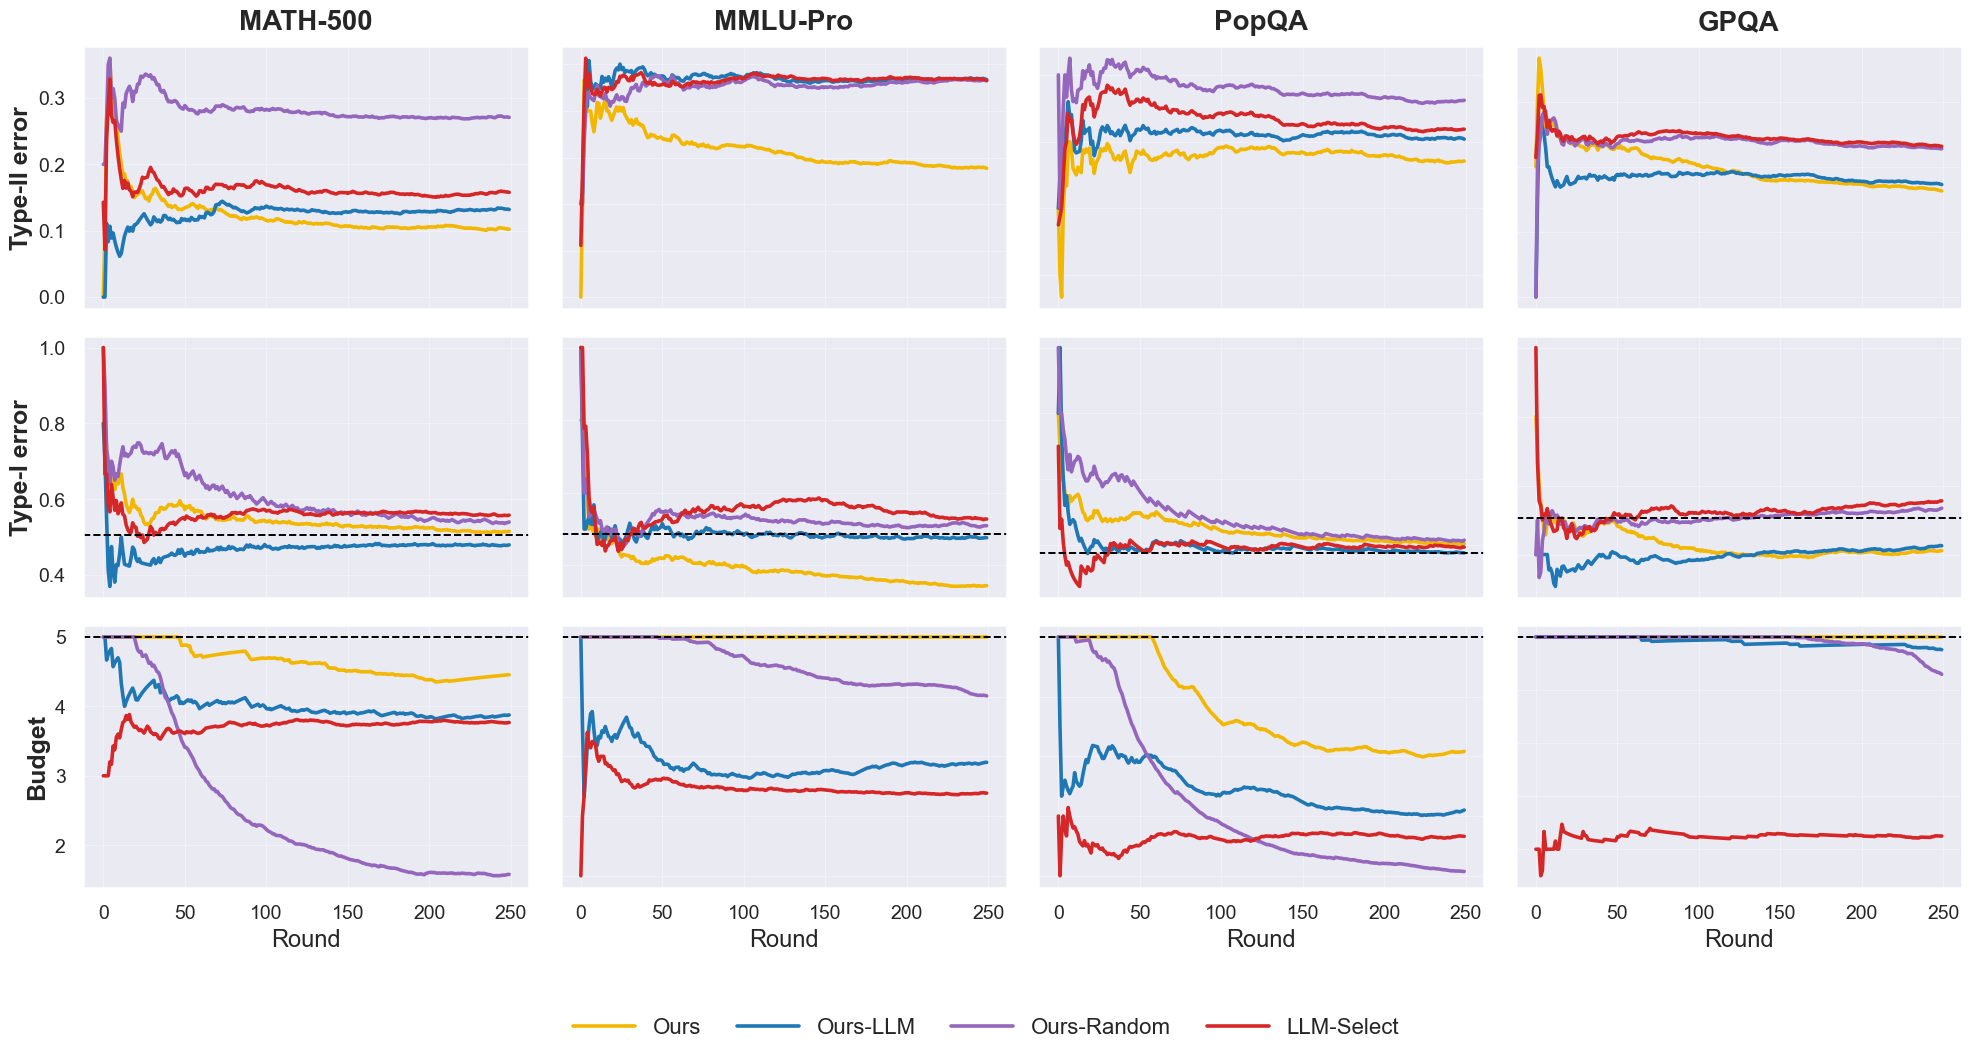

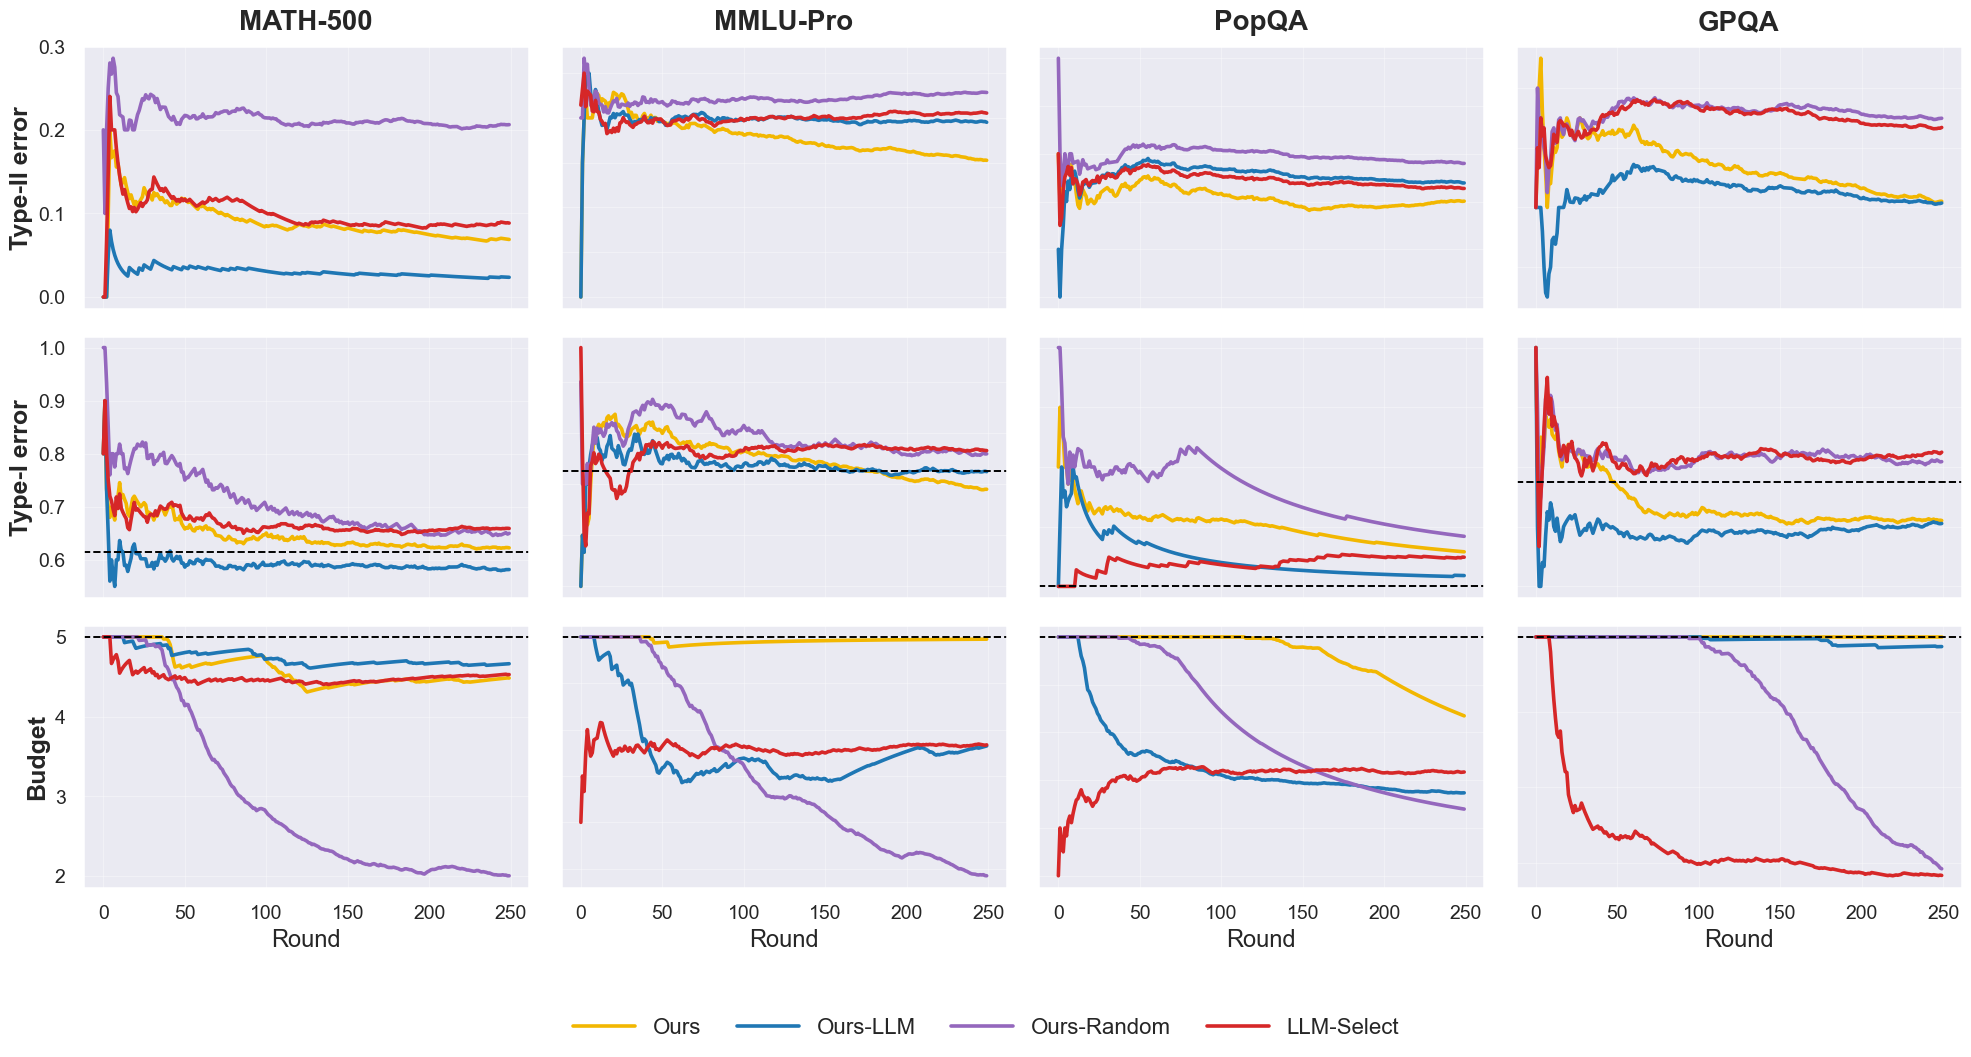

In [3]:
from pathlib import Path
from typing import Dict, List, Tuple
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(context="talk", style="darkgrid", font_scale=1.25)

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 18,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,
    "figure.titlesize": 18,
})

DATASET_ORDER = [
    "math500-test",
    "mmlupro-test_n500_seed42",
    "popqa-test_n500_seed42",
    "gpqa-train_main_n448",
]

DATASET_LABELS = {
    "math500-test": "MATH-500",
    "mmlupro-test_n500_seed42": "MMLU-Pro",
    "popqa-test_n500_seed42": "PopQA",
    "gpqa-train_main_n448": "GPQA",
    "mmlupro-test_n600_seed42_multishift": "MMLU-Pro Shift",
    "popqa-test_n600_seed42_popshift": "PopQA Shift",
}

# Type-II is now first row.
ROW_SPECS = [
    ("Cum. Type-II", "Type-II error"),
    ("Cum. Type-I", "Type-I error"),
    ("Cum. Budget", "Budget"),
]


def dataset_display_name(dataset_id: str) -> str:
    """Return the paper-facing dataset label, not the config/folder suffix."""
    dataset_id = str(dataset_id).replace("popqa500-", "popqa-")

    if dataset_id in DATASET_LABELS:
        return DATASET_LABELS[dataset_id]
    if dataset_id.startswith("math500"):
        return "MATH-500"
    if dataset_id.startswith("mmlupro"):
        return "MMLU-Pro"
    if dataset_id.startswith("popqa"):
        return "PopQA"
    if dataset_id.startswith("gpqa"):
        return "GPQA"
    return dataset_id


def infer_model_name_for_plot(row: pd.Series) -> str:
    """Prefer the explicit main_llm column; otherwise strip the dataset suffix from model_data."""
    if "main_llm" in row.index and pd.notna(row["main_llm"]):
        text = str(row["main_llm"]).strip()
        if text:
            return text

    model_data = str(row.get("model_data", "unknown_model"))
    dataset = str(row.get("dataset", ""))

    if dataset and model_data.endswith("_" + dataset):
        return model_data[: -(len(dataset) + 1)]

    return model_data


def build_model_overview_metrics(runs=("outputs",)) -> pd.DataFrame:
    raw_df = collect_run_csvs(list(runs))
    raw_df["model"] = raw_df.apply(infer_model_name_for_plot, axis=1)

    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)

    model_lookup = (
        raw_df[["model_data", "dataset", "config", "method", "run_file", "model"]]
        .drop_duplicates()
    )

    metrics = metrics.merge(
        model_lookup,
        on=["model_data", "dataset", "config", "method", "run_file"],
        how="left",
    )

    metrics["Dataset Label"] = metrics["dataset"].map(dataset_display_name)
    metrics = filter_methods_for_plot(metrics)
    return metrics


def _dedupe_legend_items(handles, labels):
    seen = set()
    out_handles = []
    out_labels = []

    for h, label in zip(handles, labels):
        if not label or label.startswith("_") or label in seen:
            continue
        seen.add(label)
        out_handles.append(h)
        out_labels.append(label)

    return out_handles, out_labels


def plot_one_model_grid(
    metrics: pd.DataFrame,
    model: str,
    out_dir: str | Path = "figures/model_grids",
    dataset_order: List[str] = DATASET_ORDER,
) -> Tuple[plt.Figure, List[List[plt.Axes]]]:
    """
    Create one 3x4 figure for a single model.

    Rows:
      1. Type-II error
      2. Type-I error
      3. Budget

    Columns:
      1. MATH-500
      2. MMLU-Pro
      3. PopQA
      4. GPQA
    """
    model_df = metrics[metrics["model"] == model].copy()

    if model_df.empty:
        raise ValueError(f"No rows found for model={model!r}")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    fig, axes = plt.subplots(
        nrows=3,
        ncols=4,
        figsize=(20.0, 11.0),
        sharex=False,
        constrained_layout=False,
    )

    all_handles = []
    all_labels = []

    for col_idx, dataset_id in enumerate(dataset_order):
        dataset_df = model_df[model_df["dataset"] == dataset_id].copy()
        dataset_title = dataset_display_name(dataset_id)

        for row_idx, (metric_col, row_label) in enumerate(ROW_SPECS):
            ax = axes[row_idx][col_idx]

            if dataset_df.empty or metric_col not in dataset_df.columns:
                ax.text(
                    0.5,
                    0.5,
                    "No data",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=15,
                )
            else:
                dataset_df = filter_methods_for_plot(dataset_df)
                method_order = [
                    m for m in METHODS_TO_PLOT
                    if m in set(dataset_df["Method"])
                ]

                sns.lineplot(
                    data=dataset_df,
                    x="Round",
                    y=metric_col,
                    hue="Method",
                    hue_order=method_order,
                    palette=METHOD_PALETTE,
                    linewidth=2.6,
                    errorbar=None,
                    ax=ax,
                    legend=True,
                )

                handles, labels = ax.get_legend_handles_labels()
                all_handles.extend(handles)
                all_labels.extend(labels)

                legend = ax.get_legend()
                if legend is not None:
                    legend.remove()

                if (
                    metric_col == "Cum. Type-I"
                    and "epsilon" in dataset_df.columns
                    and dataset_df["epsilon"].notna().any()
                ):
                    epsilon = float(dataset_df["epsilon"].dropna().iloc[0])
                    ax.axhline(
                        epsilon,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

                if (
                    metric_col == "Cum. Budget"
                    and "Limit" in dataset_df.columns
                    and dataset_df["Limit"].notna().any()
                ):
                    limit = float(dataset_df["Limit"].dropna().iloc[0])
                    ax.axhline(
                        limit,
                        linestyle="--",
                        linewidth=1.4,
                        color="black",
                        label="_nolegend_",
                    )

            # Dataset names only on the top row.
            if row_idx == 0:
                ax.set_title(dataset_title, fontsize=20, fontweight="bold", pad=12)
            else:
                ax.set_title("")

            # Y-axis labels only once on the leftmost plot of each row.
            if col_idx == 0:
                ax.set_ylabel(row_label, fontsize=18, fontweight="bold")
            else:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)

            # X-axis labels only on bottom row.
            if row_idx == 2:
                ax.set_xlabel("Round", fontsize=17)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", labelsize=14)
            ax.grid(True, alpha=0.35, linewidth=0.8)

    handles, labels = _dedupe_legend_items(all_handles, all_labels)

    if handles:
        fig.legend(
            handles,
            labels,
            title=None,
            loc="lower center",
            bbox_to_anchor=(0.5, 0.005),
            ncol=min(len(labels), 6),
            frameon=False,
            fontsize=16,
            handlelength=2.8,
            columnspacing=1.6,
        )

    # No model name above the plots.
    fig.tight_layout(rect=(0.0, 0.08, 1.0, 0.98), w_pad=1.4, h_pad=1.2)

    out_base = out_dir / f"model_grid_{safe_name(model)}"

    fig.savefig(out_base.with_suffix(".png"), bbox_inches="tight", dpi=300)
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")

    print(f"[plot] wrote {out_base.with_suffix('.png')}")
    print(f"[plot] wrote {out_base.with_suffix('.pdf')}")

    return fig, axes


metrics = build_model_overview_metrics(runs=("outputs",))

for model_name in sorted(metrics["model"].dropna().unique()):
    plot_one_model_grid(metrics, model_name)

In [ ]:
# Distribution-shift robustness figure
# Run this cell after the standard plotting/helper cells above.

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.transforms import blended_transform_factory

SHIFT_EXPERIMENT_SPECS = {
    "mmlupro-test_n600_seed42_multishift": {
        "title": "MMLU-Pro multi-domain shift",
        "subtitle": "STEM → Life/Health → Humanities/Social Science → Law/Others",
        "phases": [
            (0, 49, "STEM"),
            (50, 99, "Life / Health"),
            (100, 149, "Humanities / Social Sci."),
            (150, 199, "Law / Others"),
        ],
    },
    "popqa-test_n600_seed42_popshift": {
        "title": "PopQA popularity shift",
        "subtitle": "Head entities → Mid-popularity entities → Long-tail entities",
        "phases": [
            (0, 59, "Head"),
            (60, 119, "Middle"),
            (120, 179, "Long-tail"),
        ],
    },
}

SHIFT_METRICS_TO_PLOT = [
    ("Cum. Type-II", "Cumulative Type-II error"),
    ("Cum. Type-I", "Cumulative Type-I error"),
]


def build_shift_metrics(runs=("outputs",)) -> pd.DataFrame:
    """Collect only the new distribution-shift runs."""
    raw_df = collect_run_csvs(list(runs))
    per_round = summarize_per_round(raw_df)
    metrics = add_cumulative_metrics(per_round)
    metrics = maybe_add_epsilon(metrics, raw_df)
    metrics = filter_methods_for_plot(metrics)
    return metrics[metrics["dataset"].isin(SHIFT_EXPERIMENT_SPECS)].copy()


def _phase_color(index: int) -> str:
    # Low-saturation phase wash. These colors are deliberately subtle so the
    # method curves remain the visual foreground in paper figures.
    colors = ["#F6E8C3", "#D8E8F1", "#E6D8F2", "#DDEED6", "#F3D6D8"]
    return colors[index % len(colors)]


def decorate_shift_axis(ax, phases, metric_col: str) -> None:
    """Add phase bands, ribbon labels, and clean shift-edge markers."""
    trans = blended_transform_factory(ax.transData, ax.transAxes)

    for idx, (start, end, label) in enumerate(phases):
        ax.axvspan(start, end, color=_phase_color(idx), alpha=0.26, lw=0, zorder=0)
        mid = (start + end) / 2.0
        ax.text(
            mid,
            1.045,
            label,
            ha="center",
            va="bottom",
            transform=trans,
            fontsize=10.5,
            fontweight="semibold",
            bbox={
                "boxstyle": "round,pad=0.28,rounding_size=0.12",
                "fc": "white",
                "ec": "0.35",
                "lw": 0.65,
                "alpha": 0.95,
            },
            clip_on=False,
            zorder=6,
        )

    # Draw shift edges as a narrow translucent column plus a dashed spine. This
    # is easier to read than a single line after resizing for a paper column.
    for start, _, _ in phases[1:]:
        edge = start - 0.5
        ax.axvspan(edge - 0.8, edge + 0.8, color="black", alpha=0.055, lw=0, zorder=1)
        ax.axvline(edge, color="0.12", lw=1.25, linestyle=(0, (3.0, 2.0)), zorder=3)
        ax.text(
            edge,
            0.965,
            "distribution\nshift",
            ha="center",
            va="top",
            rotation=90,
            transform=trans,
            fontsize=8.5,
            color="0.18",
            bbox={"boxstyle": "round,pad=0.15", "fc": "white", "ec": "none", "alpha": 0.78},
            zorder=7,
        )

    ax.set_xlim(phases[0][0], phases[-1][1])
    ax.grid(True, alpha=0.25, linewidth=0.75)

    if metric_col == "Cum. Type-I":
        ax.set_ylim(bottom=0)
    elif metric_col == "Cum. Type-II":
        ax.set_ylim(bottom=0)


def plot_distribution_shift_figure(
    runs=("outputs",),
    out_dir: str | Path = "figures/distribution_shift",
    metrics_to_plot=SHIFT_METRICS_TO_PLOT,
):
    """Create the paper-ready distribution-shift robustness figure."""
    shift_metrics = build_shift_metrics(runs=runs)
    if shift_metrics.empty:
        raise RuntimeError(
            "No distribution-shift run CSVs found. Run the new multishift/popshift configs first."
        )

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    dataset_ids = [d for d in SHIFT_EXPERIMENT_SPECS if d in set(shift_metrics["dataset"])]
    fig, axes = plt.subplots(
        nrows=len(metrics_to_plot),
        ncols=len(dataset_ids),
        figsize=(7.4 * len(dataset_ids), 7.0),
        sharex=False,
        constrained_layout=False,
    )
    if len(metrics_to_plot) == 1:
        axes = [axes]
    if len(dataset_ids) == 1:
        axes = [[ax] for ax in axes]

    all_handles = []
    all_labels = []

    for col_idx, dataset_id in enumerate(dataset_ids):
        spec = SHIFT_EXPERIMENT_SPECS[dataset_id]
        dataset_df = shift_metrics[shift_metrics["dataset"] == dataset_id].copy()
        method_order = [m for m in METHODS_TO_PLOT if m in set(dataset_df["Method"])]

        for row_idx, (metric_col, y_label) in enumerate(metrics_to_plot):
            ax = axes[row_idx][col_idx]
            decorate_shift_axis(ax, spec["phases"], metric_col)

            sns.lineplot(
                data=dataset_df,
                x="Round",
                y=metric_col,
                hue="Method",
                hue_order=method_order,
                palette=METHOD_PALETTE,
                linewidth=2.8,
                errorbar=None,
                ax=ax,
                legend=True,
                zorder=5,
            )

            handles, labels = ax.get_legend_handles_labels()
            all_handles.extend(handles)
            all_labels.extend(labels)
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

            if metric_col == "Cum. Type-I" and "epsilon" in dataset_df.columns and dataset_df["epsilon"].notna().any():
                epsilon = float(dataset_df["epsilon"].dropna().iloc[0])
                ax.axhline(epsilon, color="0.10", lw=1.15, linestyle=(0, (4, 2)), zorder=4)
                ax.text(
                    spec["phases"][-1][1],
                    epsilon,
                    r"  $\epsilon$",
                    va="center",
                    ha="left",
                    fontsize=10.5,
                    color="0.10",
                )

            if row_idx == 0:
                ax.set_title(f"{spec['title']}\n{spec['subtitle']}", fontsize=14.5, fontweight="bold", pad=30)
            else:
                ax.set_title("")

            if col_idx == 0:
                ax.set_ylabel(y_label, fontsize=13.5, fontweight="bold")
            else:
                ax.set_ylabel("")
            if row_idx == len(metrics_to_plot) - 1:
                ax.set_xlabel("Online batch", fontsize=12.5)
            else:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

            ax.tick_params(axis="both", labelsize=10.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    handles, labels = _dedupe_legend_items(all_handles, all_labels)
    if handles:
        fig.legend(
            handles,
            labels,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.01),
            ncol=min(len(labels), 5),
            frameon=False,
            fontsize=12.5,
            handlelength=2.6,
            columnspacing=1.4,
        )

    fig.suptitle("Robustness under sequential distribution shifts", y=1.035, fontsize=17, fontweight="bold")
    fig.tight_layout(rect=(0.0, 0.065, 1.0, 0.98), w_pad=1.6, h_pad=2.3)

    out_base = out_dir / "distribution_shift_robustness"
    fig.savefig(out_base.with_suffix(".png"), bbox_inches="tight", dpi=300)
    fig.savefig(out_base.with_suffix(".pdf"), bbox_inches="tight")
    print(f"[plot] wrote {out_base.with_suffix('.png')}")
    print(f"[plot] wrote {out_base.with_suffix('.pdf')}")
    return fig, axes, shift_metrics


shift_fig, shift_axes, shift_metrics = plot_distribution_shift_figure(runs=("outputs",))
